# 1P parameter sweep: is feedback really invisible, or just swamped?

In the LH fixed-N result (notebook 02), every simulation varies all 6
parameters at once, so each parameter's quartile-contrast response is
marginalized over the other 5 -- adding noise on top of any real-but-small
feedback signal. The **1P set** varies one parameter at a time with the
others held at fiducial, removing that marginalization noise entirely.

**This particular 1P set turns out to vary 28 astrophysics parameters
(`WindEnergyIn1e51erg`, `RadioFeedbackFactor`, `BlackHoleFeedbackFactor`,
...), not the LH run's 4 lumped ones (`A_SN1`/`A_AGN1`/`A_SN2`/`A_AGN2`)** --
confirmed empirically in section 1 below, not assumed. Only the 2
cosmological columns (`Omega0`/`sigma8`) correspond directly to
`Omega_m`/`sigma_8` and are checked against LH's dominant signal as a sanity
check; the 28 astrophysics columns are a finer decomposition of feedback
physics with no 1:1 match to LH's 4, so they're analyzed and ranked on their
own terms -- "does *any* of this richer decomposition show a real trend",
not a literal re-test of `A_SN1` etc.

**Nothing about the 1P set's directory naming, grid size, step spacing, or
which column each varied index corresponds to is assumed.** Section 1
discovers it from what's actually on disk and the 1P parameter table;
section 2 verifies the index -> column mapping empirically before trusting
it.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd

from src import config
from src.data_io import find_snapshots
from src.params import load_1p_params
from src.onep import (
    parse_1p_label, infer_1p_parameter_names, mean_cdf_by_step, monotonic_trend,
    step_label, fiducial_value, COSMO_ALIASES,
)
from src.pipeline import run_suite
from src.sensitivity import infer_layout, benjamini_hochberg
from src.plotting import plot_1p_sweep

SIM_PATH_1P = config.SIM_PATH_1P
PARAMS_FILE_1P = config.PARAMS_FILE_1P
OUTPUT_DIR = config.OUTPUT_DIR

## 1. What's actually on disk?

Lists every 1P snapshot found, how many parameters are varied and with what
step set, and the parameter table's shape -- before assuming any of it.

In [2]:
files_1p = find_snapshots(SIM_PATH_1P, config.SNAP, prefix="1P_")
print(f"Found {len(files_1p)} 1P snapshots at snap={config.SNAP}")

labels = sorted({f.split("1P_")[1].split("/")[0] for f in files_1p})
parsed = {l: parse_1p_label(l) for l in labels}

n_fiducial = sum(1 for p, _ in parsed.values() if p is None)
param_steps = {}
for p, s in parsed.values():
    if p is None:
        continue
    param_steps.setdefault(p, []).append(s)

steps_per_param = pd.Series({p: sorted(s) for p, s in param_steps.items()}).sort_index()

print(f"\nShared fiducial ('0') snapshots: {n_fiducial}")
print(f"Parameters varied: {len(steps_per_param)}")
print("\nStep count per parameter:")
print(steps_per_param.apply(len).value_counts().sort_index())

step_sets = steps_per_param.apply(tuple)
modal = step_sets.value_counts().idxmax()
irregular = step_sets[step_sets != modal]

print(f"\nModal step set: {modal}")
if len(irregular):
    print("Parameters with a DIFFERENT step set (worth a manual look):")
    print(irregular)
else:
    print("Every parameter has the same step set.")

theta_1p_all = load_1p_params(PARAMS_FILE_1P)
print(f"\nParameter table: {theta_1p_all.shape[0]} rows, columns = {list(theta_1p_all.columns)}")

# The simulations dedupe the fiducial to one shared snapshot ("1P_0" above),
# but the parameter table documenting each named recipe isn't guaranteed to
# mirror that -- it may instead list a separate fiducial row per parameter
# (e.g. "p1_0", "p2_0", ...). Report which it is rather than assume: this is
# exactly why fiducial_value() (used below) looks up the fiducial by most-
# common-value rather than by a literal "0" label.
rows_per_param = theta_1p_all.shape[0] / len(steps_per_param) if len(steps_per_param) else float("nan")
print(f"\nParameter table rows per varied parameter: {rows_per_param:.2f} "
      f"({'looks like a per-parameter fiducial row' if abs(rows_per_param - (len(modal) + 1)) < 0.5 else 'unclear'})")
print(f"Literal '0' row present in parameter table: {'0' in theta_1p_all.index}")

Found 113 1P snapshots at snap=50

Shared fiducial ('0') snapshots: 1
Parameters varied: 28

Step count per parameter:
4    28
Name: count, dtype: int64

Modal step set: (-2, -1, 1, 2)
Parameters with a DIFFERENT step set (worth a manual look):
15    (1, 2, 3, 4)
dtype: object

Parameter table: 140 rows, columns = ['Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 'VariableWindVelFactor', 'RadioFeedbackReiorientationFactor', 'OmegaBaryon', 'HubbleParam', 'n_s', 'MaxSfrTimescale', 'FactorForSofterEQS', 'IMFslope', 'SNII_MinMass_Msun', 'ThermalWindFraction', 'VariableWindSpecMomentum', 'WindFreeTravelDensFac', 'MinWindVel', 'WindEnergyReductionFactor', 'WindEnergyReductionMetallicity', 'WindEnergyReductionExponent', 'WindDumpFactor', 'SeedBlackHoleMass', 'BlackHoleAccretionFactor', 'BlackHoleEddingtonFactor', 'BlackHoleFeedbackFactor', 'BlackHoleRadiativeEfficiency', 'QuasarThreshold', 'QuasarThresholdPower', 'seed']

Parameter table rows per varied parameter: 5.00 (looks

## 2. Verify the parameter-index -> column mapping

Checks which single column of the parameter table actually varies within
each index group, discovered from the table's own columns -- not assumed to
be `config.ALL_PARAMS` (the LH set's 6 names), since this 1P set's own
parameterization can be, and here is, entirely different. Splits the result
into the 2 columns directly comparable to LH (`Omega_m`/`sigma_8`) and the
rest, this suite's own astrophysics decomposition. Any group in `ambiguous`
needs a manual look before proceeding.

In [3]:
mapping, ambiguous = infer_1p_parameter_names(theta_1p_all)

print(f"Resolved {len(mapping)} of {len(mapping) + len(ambiguous)} groups cleanly.")
if ambiguous:
    print("AMBIGUOUS groups (inspect by hand):", ambiguous)
assert not ambiguous, "Resolve ambiguous groups before trusting the mapping below."

cosmo_mapping = {pidx: name for pidx, name in mapping.items() if name in COSMO_ALIASES}
astro_mapping = {pidx: name for pidx, name in mapping.items() if name not in COSMO_ALIASES}

print(f"\nCosmological ({len(cosmo_mapping)}, directly comparable to LH):")
for pidx, name in sorted(cosmo_mapping.items()):
    print(f"  index {pidx}: {name}  (LH: {COSMO_ALIASES[name]})")

print(f"\nAstrophysics ({len(astro_mapping)}, this suite's own decomposition -- "
      f"not a 1:1 match to LH's A_SN1/A_AGN1/A_SN2/A_AGN2):")
for pidx, name in sorted(astro_mapping.items()):
    print(f"  index {pidx}: {name}")

Resolved 28 of 28 groups cleanly.

Cosmological (2, directly comparable to LH):
  index 1: Omega0  (LH: Omega_m)
  index 2: sigma8  (LH: sigma_8)

Astrophysics (26, this suite's own decomposition -- not a 1:1 match to LH's A_SN1/A_AGN1/A_SN2/A_AGN2):
  index 3: WindEnergyIn1e51erg
  index 4: RadioFeedbackFactor
  index 5: VariableWindVelFactor
  index 6: RadioFeedbackReiorientationFactor
  index 7: OmegaBaryon
  index 8: HubbleParam
  index 9: n_s
  index 10: MaxSfrTimescale
  index 11: FactorForSofterEQS
  index 12: IMFslope
  index 13: SNII_MinMass_Msun
  index 14: ThermalWindFraction
  index 15: VariableWindSpecMomentum
  index 16: WindFreeTravelDensFac
  index 17: MinWindVel
  index 18: WindEnergyReductionFactor
  index 19: WindEnergyReductionMetallicity
  index 20: WindEnergyReductionExponent
  index 21: WindDumpFactor
  index 22: SeedBlackHoleMass
  index 23: BlackHoleAccretionFactor
  index 24: BlackHoleEddingtonFactor
  index 25: BlackHoleFeedbackFactor
  index 26: BlackHoleRad

## 3. Generate fixed-N AGN summaries over the 1P set

Same `N_TARGET`/`mass_cut`/`kvals`/`rgrid` as the LH fixed-N run (notebook
02), read from its saved `.npz`, so results are directly comparable.

In [4]:
import glob

agn_candidates = sorted(glob.glob(f"{OUTPUT_DIR}/agn_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n*.npz"))
assert agn_candidates, f"No LH AGN fixed-N run found in {OUTPUT_DIR} -- run notebook 02 first."
agn_data = np.load(agn_candidates[-1], allow_pickle=True)
N_TARGET = int(agn_data["nbh"][0])
print(f"N_TARGET = {N_TARGET} (from the LH AGN run)")

N_TARGET = 286 (from the LH AGN run)


In [5]:
GENERATE = True

onep_path = f"{OUTPUT_DIR}/1p_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n{N_TARGET}.npz"

if GENERATE:
    result = run_suite(
        n_target=N_TARGET, tracer="luminosity",
        sim_path=SIM_PATH_1P, output_dir=OUTPUT_DIR,
        dir_prefix="1P_", numeric_id=False,
    )
else:
    data = np.load(onep_path, allow_pickle=True)
    result = {k: data[k] for k in ("sim_ids", "summaries", "nbh", "rgrid", "kvals")}

sim_ids = result["sim_ids"]
summaries = result["summaries"]
rgrid = result["rgrid"]
kvals = result["kvals"]
n_k, n_r = infer_layout(kvals, rgrid)

print(f"{len(sim_ids)} 1P simulations retained at N={N_TARGET}, summary shape {summaries.shape}")
print(f"dropped: {len(files_1p) - len(sim_ids)} / {len(files_1p)} (too few eligible AGN at this N)")

Found 113 snapshots


100%|██████████| 113/113 [01:07<00:00,  1.69it/s]



Saved: ../outputs/1p_knn_snap50_M1e+06_n286.npz
Successful runs = 110 / 113
Summary shape   = (110, 150)
N_AGN: mean 286.0, min 286, max 286
110 1P simulations retained at N=286, summary shape (110, 150)
dropped: 3 / 113 (too few eligible AGN at this N)


## 4. Trend test, per parameter

One scalar response per parameter (mean CDF at a fixed, physically-motivated
probe bin: r~4 Mpc/h, k=1 -- where the LH `Omega_m` signal peaked), tested
for a monotonic trend against the parameter's own values. Plots: always for
the 2 cosmological parameters (the LH sanity check); for astrophysics, only
the top few by significance -- 28 individual panels isn't readable, and
`trend_df` below is the actual ranked result.

In [6]:
probe_r = np.argmin(np.abs(rgrid - 4.0))
results_by_param = {}
trend_rows = []

for pidx, name in sorted(mapping.items()):
    steps, mean_cdfs = mean_cdf_by_step(summaries, sim_ids, param_index=pidx, n_k=n_k, n_r=n_r)

    if len(steps) == 0:
        print(f"{name}: no retained simulations at N={N_TARGET}, skipping")
        continue

    # step 0 (the shared fiducial) has no single reconstructable label in
    # the parameter table -- see fiducial_value()'s docstring for why.
    step_values = np.array([
        fiducial_value(theta_1p_all, name) if s == 0 else theta_1p_all.loc[step_label(pidx, s), name]
        for s in steps
    ])

    order = np.argsort(step_values)
    step_values, mean_cdfs = step_values[order], mean_cdfs[order]
    results_by_param[name] = (step_values, mean_cdfs)

    if len(step_values) >= 3:
        rho, p = monotonic_trend(step_values, mean_cdfs[:, 0, probe_r])
        trend_rows.append({
            "parameter": name,
            "group": "cosmological" if name in COSMO_ALIASES else "astrophysics",
            "n_steps": len(step_values),
            "spearman_rho": rho,
            "p_value": p,
        })
    else:
        print(f"{name}: only {len(step_values)} step(s) retained, too few for a trend test")

trend_df = pd.DataFrame(trend_rows)

# FDR-correct within each group separately: the 28 astrophysics parameters
# are an exploratory scan (multiple-testing risk is real -- a synthetic
# dry run of this exact pipeline turned up |rho|>=0.9, nominal p<0.05 for
# 2/28 *pure-noise* parameters purely from the n~5 sample size), while the
# 2 cosmological parameters are a single targeted check against LH's known
# result, not part of that scan.
trend_df["q_value"] = np.nan
for group, idx in trend_df.groupby("group").groups.items():
    trend_df.loc[idx, "q_value"] = benjamini_hochberg(trend_df.loc[idx, "p_value"].values)
trend_df["significant"] = trend_df["q_value"] < 0.05

trend_df = trend_df.sort_values("q_value").reset_index(drop=True)
trend_df

,parameter,group,n_steps,spearman_rho,p_value,q_value,significant
0,Omega0,cosmological,4,1.0,0.083333,0.166667,False
1,BlackHoleFeedbackFactor,astrophysics,5,-1.0,0.016667,0.216667,False
2,HubbleParam,astrophysics,5,1.0,0.016667,0.216667,False
3,QuasarThreshold,astrophysics,5,0.9,0.083333,0.270833,False
4,MaxSfrTimescale,astrophysics,5,-0.9,0.083333,0.270833,False
5,OmegaBaryon,astrophysics,5,-0.9,0.083333,0.270833,False
6,n_s,astrophysics,5,0.9,0.083333,0.270833,False
7,BlackHoleAccretionFactor,astrophysics,5,-0.9,0.083333,0.270833,False
8,WindEnergyReductionFactor,astrophysics,5,-0.9,0.083333,0.270833,False
9,WindEnergyIn1e51erg,astrophysics,5,-0.8,0.133333,0.315152,False


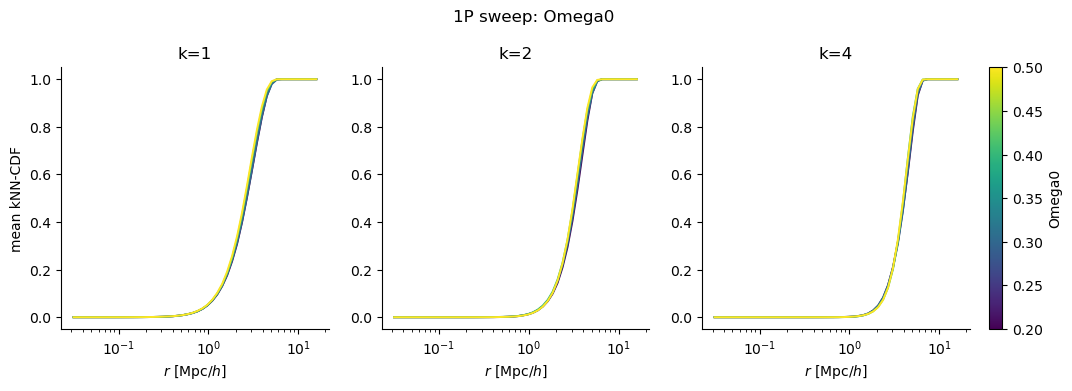

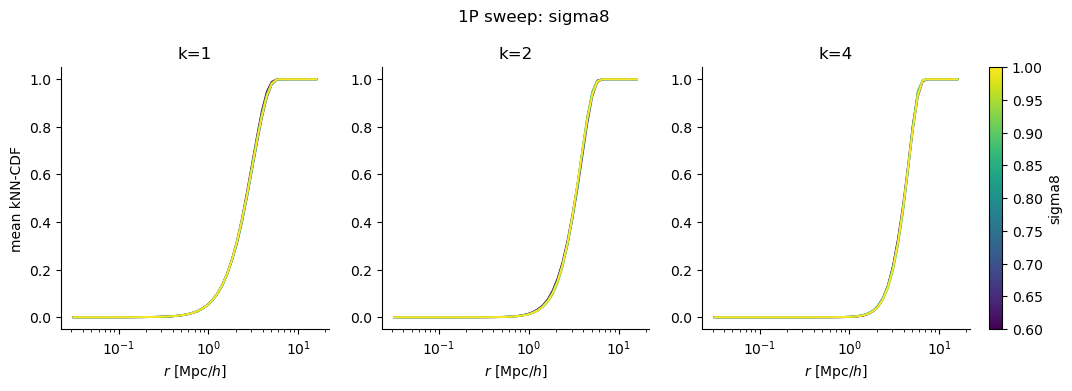

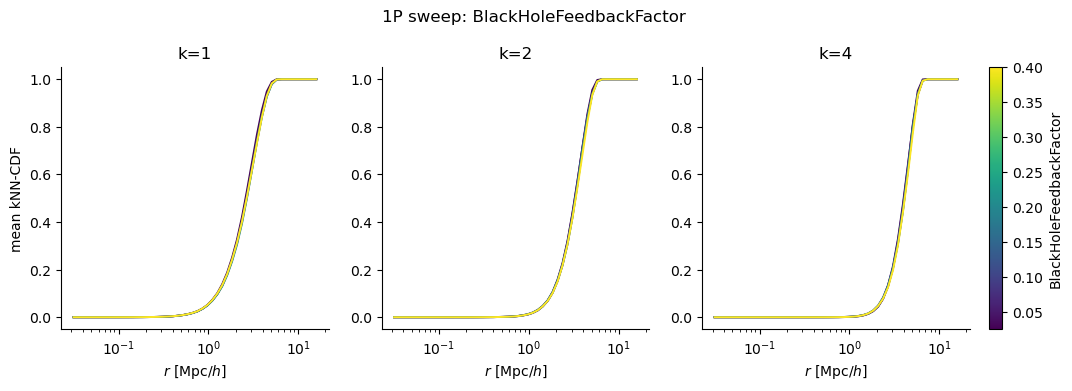

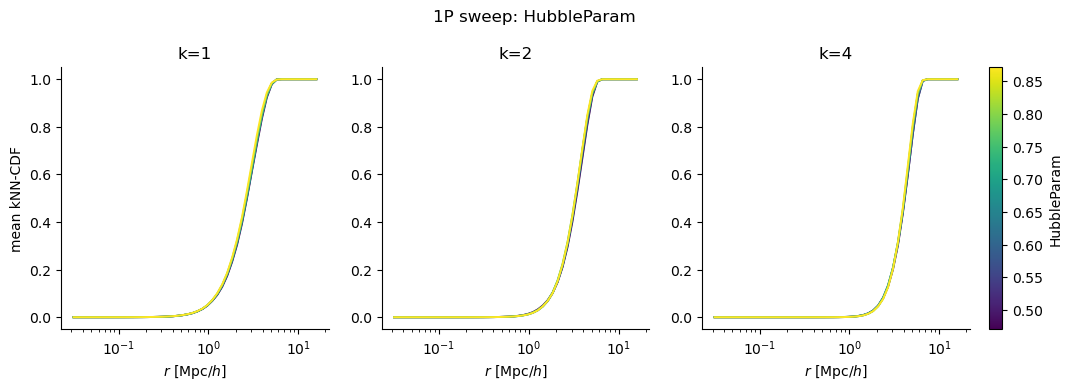

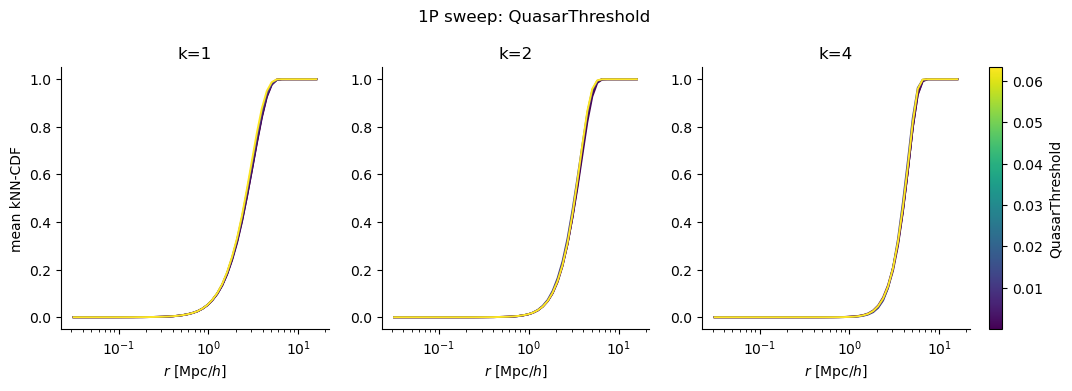

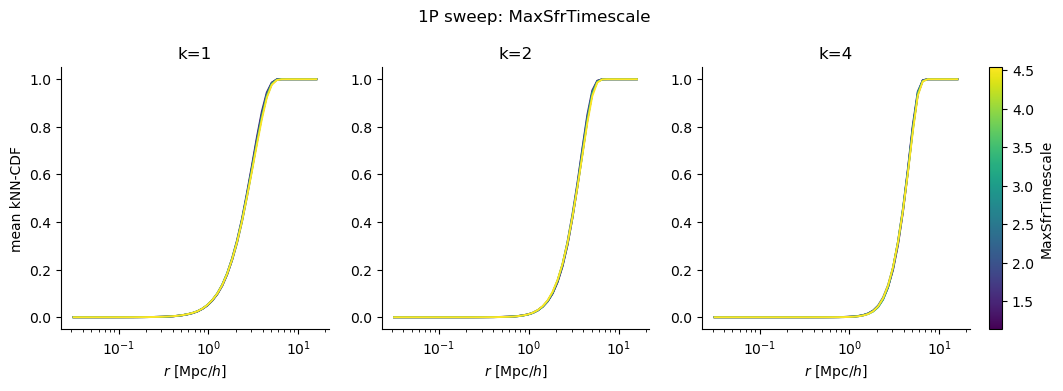

In [7]:
N_TOP_ASTRO = 4  # how many astrophysics parameters to plot, by significance

for name in COSMO_ALIASES:
    if name in results_by_param:
        step_values, mean_cdfs = results_by_param[name]
        plot_1p_sweep(rgrid, kvals, step_values, mean_cdfs, name)

top_astro = trend_df.loc[trend_df["group"] == "astrophysics", "parameter"].head(N_TOP_ASTRO)
for name in top_astro:
    step_values, mean_cdfs = results_by_param[name]
    plot_1p_sweep(rgrid, kvals, step_values, mean_cdfs, name)

## Reading this

`trend_df` is a monotonicity check at one fixed, physically-motivated bin
(r~4 Mpc/h, k=1), not a full scale-resolved significance test like
`sensitivity_table`. `p_value` is an **exact permutation p-value**
(`monotonic_trend` enumerates every possible ranking of the response at
this n and asks how often a random one would produce |rho| this extreme)
-- not `scipy.stats.spearmanr`'s own p-value, which uses a large-sample
approximation that is badly overconfident at the tiny n a 1P sweep has: on
a real run it reported p=1.4e-24 for a perfect n=5 rank correlation, versus
the true exact value 2/5!=0.017; at n=4 it reported p=0.0 for a perfect
correlation whose exact p-value is 2/4!=0.083 -- not even significant at
the 5% level. `q_value`/`significant` are FDR-corrected (Benjamini-
Hochberg, as in the LH analysis) *within* each group separately,
astrophysics against astrophysics and cosmological against cosmological,
since the 26 astrophysics parameters are an exploratory scan while the 2
cosmological ones are a single targeted check against LH's already-known
result.

**Set expectations accordingly: at n=4-5 points, don't expect anything to
clear FDR-corrected significance, even a real effect.** A perfect n=5
correlation alone is only p=0.017 before any FDR correction; run the same
recompute this notebook does and even `Omega_m`'s own row -- a signal
confirmed at extremely high confidence in the 1000-simulation LH analysis
-- comes out around q~0.17, not significant, purely because n=4-5 caps how
small a permutation p-value can ever get. That is the honest, correct
statistical conclusion for this sample size, not a bug: **treat this
notebook's ranking of parameters by `rho` (or by raw `p_value`) as
exploratory/descriptive -- "which subgrid knobs look most promising to
chase further" -- rather than as confirmed detections.** A real detection
at this n would need either more 1P steps or repeated seeds per step
(neither exists in this release) to ever be statistically demonstrable, not
a different test.

Two more things temper how much weight any single row carries even before
that:

- **No repeated seeds per step** in this release, so each point is a
  single noisy realization regardless of which p-value is used.
- **Different questions for the two groups.** The cosmological rows are
  the same physical quantities as LH's `Omega_m`/`sigma_8`. The
  astrophysics rows are **not** a re-test of LH's
  `A_SN1`/`A_AGN1`/`A_SN2`/`A_AGN2` -- they're this suite's own, unrelated
  finer decomposition of feedback physics, so a high-`rho` astrophysics row
  says "this specific subgrid knob is worth a closer look," not "LH's
  4 lumped parameters were noise-swamped" (they aren't the same
  parameterization).